Compute Pearson correlation coefficient with n_lesions/volume and all features

In [8]:
import pandas as pd
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
import numpy as np

In [49]:
# df = pd.read_csv(r"D:\DP\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df = pd.read_csv(r"D:\DP\CSV\merged_konv_radiomics_spine_lesions_features.csv")
# df = pd.read_csv(r"D:\DP\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
# df = pd.read_csv(r"D:\DP\CSV\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
# df = pd.read_csv(r"D:\DP\CSV\merged_monoe_120kev_radiomics_spine_lesions_features.csv")

# df = pd.read_csv(r"D:\DP\ALL\m_001\CaSupp_25_radiomics_lesions_features.csv")

df = df.drop(columns=["patient"])
# df = df.drop(columns=["vertebra_name"])

In [50]:
# Assuming n_lesions is the first column now
target = "original_shape_VoxelVolume"

correlations = []
for col in df.columns:
    if col != target:
        r, p = pearsonr(df[target], df[col])
        correlations.append({"Feature": col, "r": r, "p_value": p})

corr_df = pd.DataFrame(correlations)

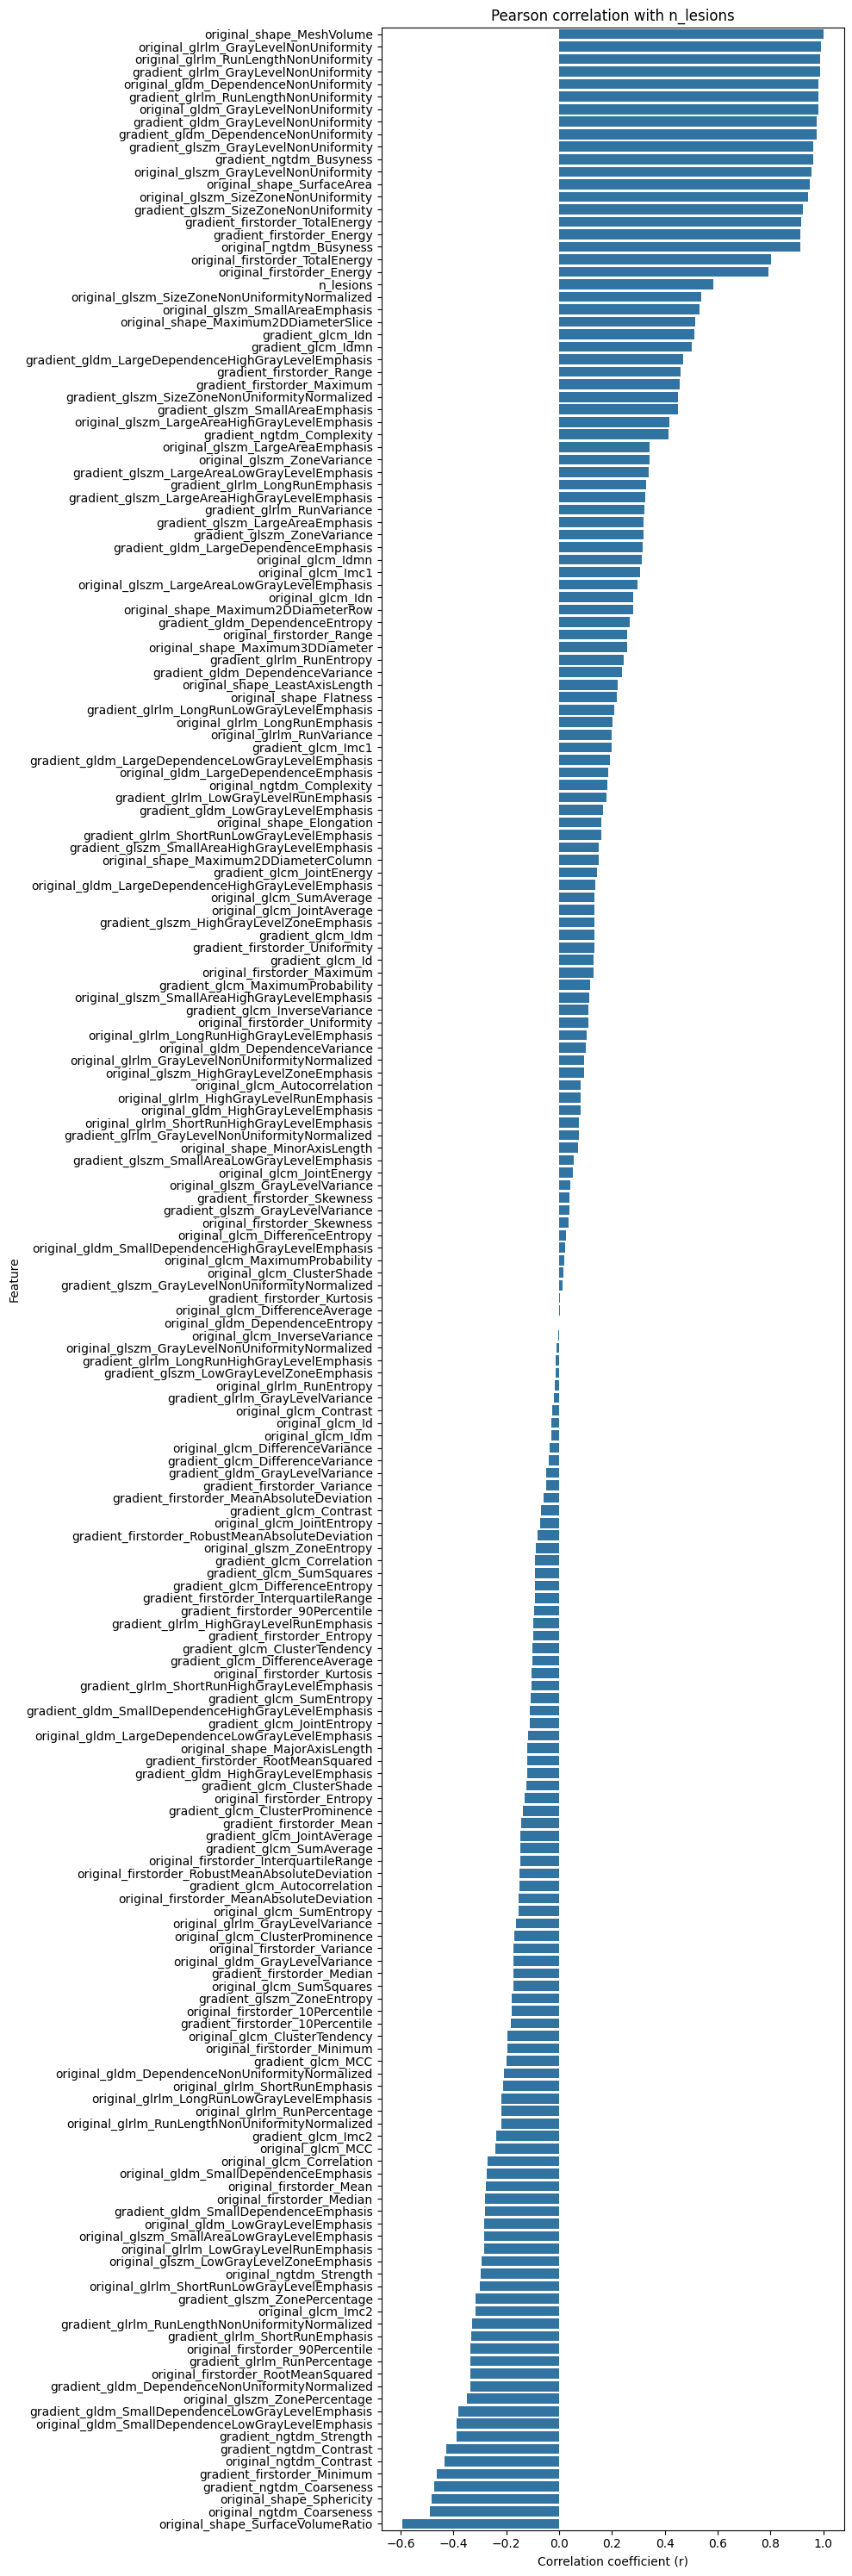

In [51]:
plt.figure(figsize=(10, 30))
sns.barplot(x="r", y="Feature", data=corr_df.sort_values("r", ascending=False))
plt.title("Pearson correlation with n_lesions")
plt.xlabel("Correlation coefficient (r)")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()

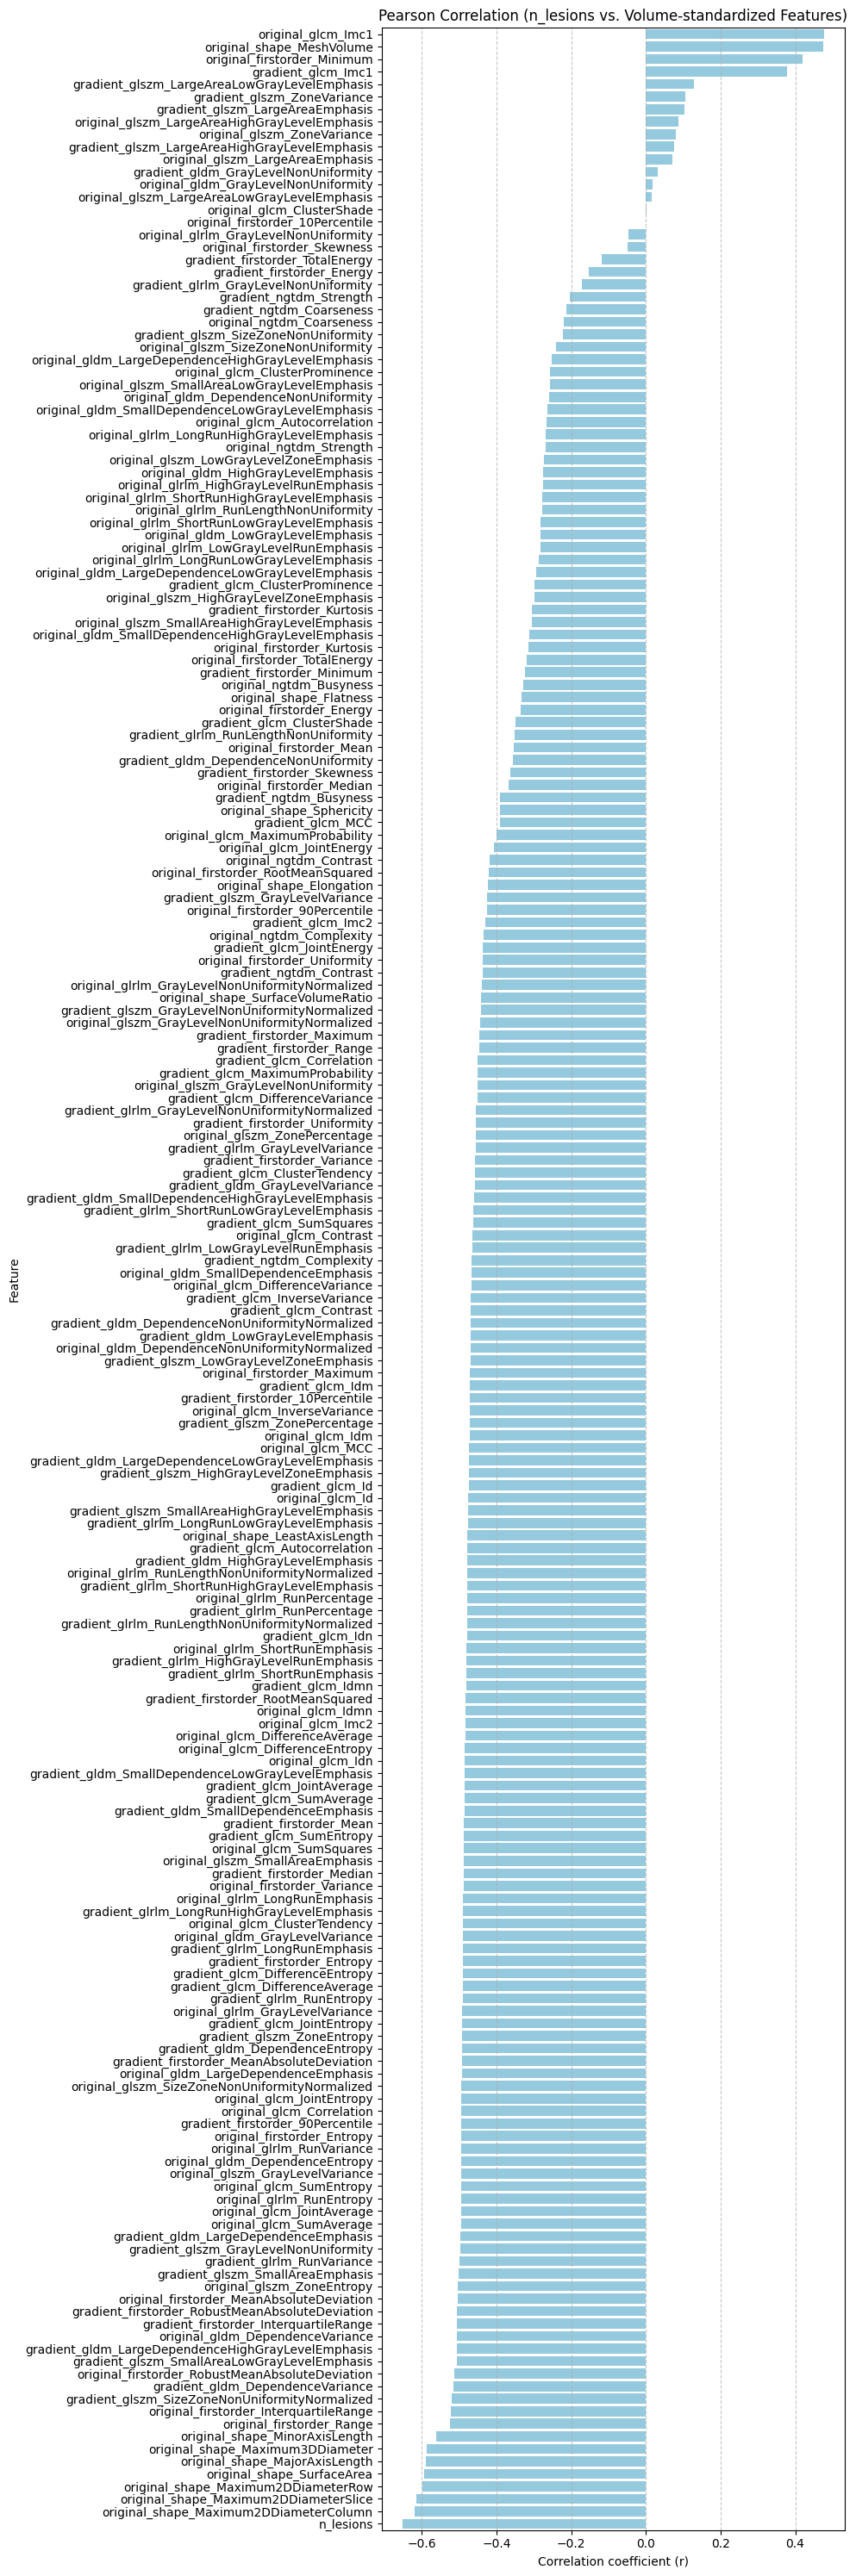

In [52]:
# STANDARDIZED BY VOLUME
target = "original_shape_VoxelVolume"
volume_col = "original_shape_VoxelVolume"

df_std = df.copy()

for col in df.columns:
    if col not in [target, volume_col]:
        df_std[col] = df[col] / df[volume_col]

# Compute Pearson correlation (n_lesions vs. standardized features)
correlations = []
for col in df_std.columns:
    if col not in [target, volume_col]:
        r, p = pearsonr(df_std[target], df_std[col])
        correlations.append({"Feature": col, "r": r, "p_value": p})

corr_df = pd.DataFrame(correlations).sort_values(by="r", ascending=False)

# Visualize correlations ---
plt.figure(figsize=(10, 30))
sns.barplot(x="r", y="Feature", data=corr_df.sort_values("r", ascending=False), color="skyblue")
plt.title("Pearson Correlation (n_lesions vs. Volume-standardized Features)")
plt.xlabel("Correlation coefficient (r)")
plt.ylabel("Feature")
plt.grid(axis="x", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.show()

CLINICAL DATA ANALYSIS

In [10]:
# Load clinical dataset
df = pd.read_csv(r"D:\DP\Table_clinical_data.csv", encoding="cp1252")
df.head()

,Patient ID,line of treatment,M-protein type,Light chain type,Serum M-protein quantity (g/l),Serum kappa FLC quantity (mg/l,Serum lambda FLC quantity (mg/l),IgG quantity (g/l),IgA quantity (g/l),IgM quantity (g/l),Plasmocyte count FC (%),Flow cytometry – circulating plasma cells (peripheral blood),Calcium total level (mmol/l),Creatinine level (µmol/l),Beta2 microglobulin (mg/l),ISS classification,Treatment regimen,Maximal response to treatment,MM associated amyloidosis,Follow - up
0,Myel_001,1st line,IgG,Kappa,21.4,143.00,9.25,32.87,1.59,0.82,0.86,NaN,2.37,81.0,2.02,Stage 1,bortezomib + lenalidomid + dexamethason,MR,no,NaN
1,Myel_002,1st line,IgA,Kappa,1.0,8870.00,2.10,1.90,0.73,0.05,12.00,NaN,2.44,51.0,4.71,Stage 2,bortezomib + cyklofosfamid + dexamethason,NaN,no,NaN
2,Myel_003,1st line,IgG,Kappa,1.1,287.00,7.46,6.66,0.87,0.28,6.50,yes,2.46,56.0,1.57,Stage 1,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN
3,Myel_004,1st line,IgA,Kappa,0.0,1585.17,4.64,6.30,2.23,0.51,NaN,NaN,2.24,169.0,5.89,Stage 3,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN
4,Myel_005,1st line,IgA,Lambda,14.8,23.40,1219.00,4.48,30.19,0.14,4.00,yes,2.22,189.0,15.75,Stage 3,bortezomib + lenalidomid + dexamethason,VGPR,no,NaN


In [12]:
# Get rid of no continuos values
drop_columns = ["Patient ID", "line of treatment", "M-protein type", "Light chain type",
                "Flow cytometry – circulating plasma cells (peripheral blood)", "ISS classification",
                "Treatment regimen", "Maximal response to treatment", "MM associated amyloidosis", "Follow - up"]

df = df.drop(columns=drop_columns)
df.head()

,Serum M-protein quantity (g/l),Serum kappa FLC quantity (mg/l,Serum lambda FLC quantity (mg/l),IgG quantity (g/l),IgA quantity (g/l),IgM quantity (g/l),Plasmocyte count FC (%),Calcium total level (mmol/l),Creatinine level (µmol/l),Beta2 microglobulin (mg/l)
0,21.4,143.00,9.25,32.87,1.59,0.82,0.86,2.37,81.0,2.02
1,1.0,8870.00,2.10,1.90,0.73,0.05,12.00,2.44,51.0,4.71
2,1.1,287.00,7.46,6.66,0.87,0.28,6.50,2.46,56.0,1.57
3,0.0,1585.17,4.64,6.30,2.23,0.51,NaN,2.24,169.0,5.89
4,14.8,23.40,1219.00,4.48,30.19,0.14,4.00,2.22,189.0,15.75


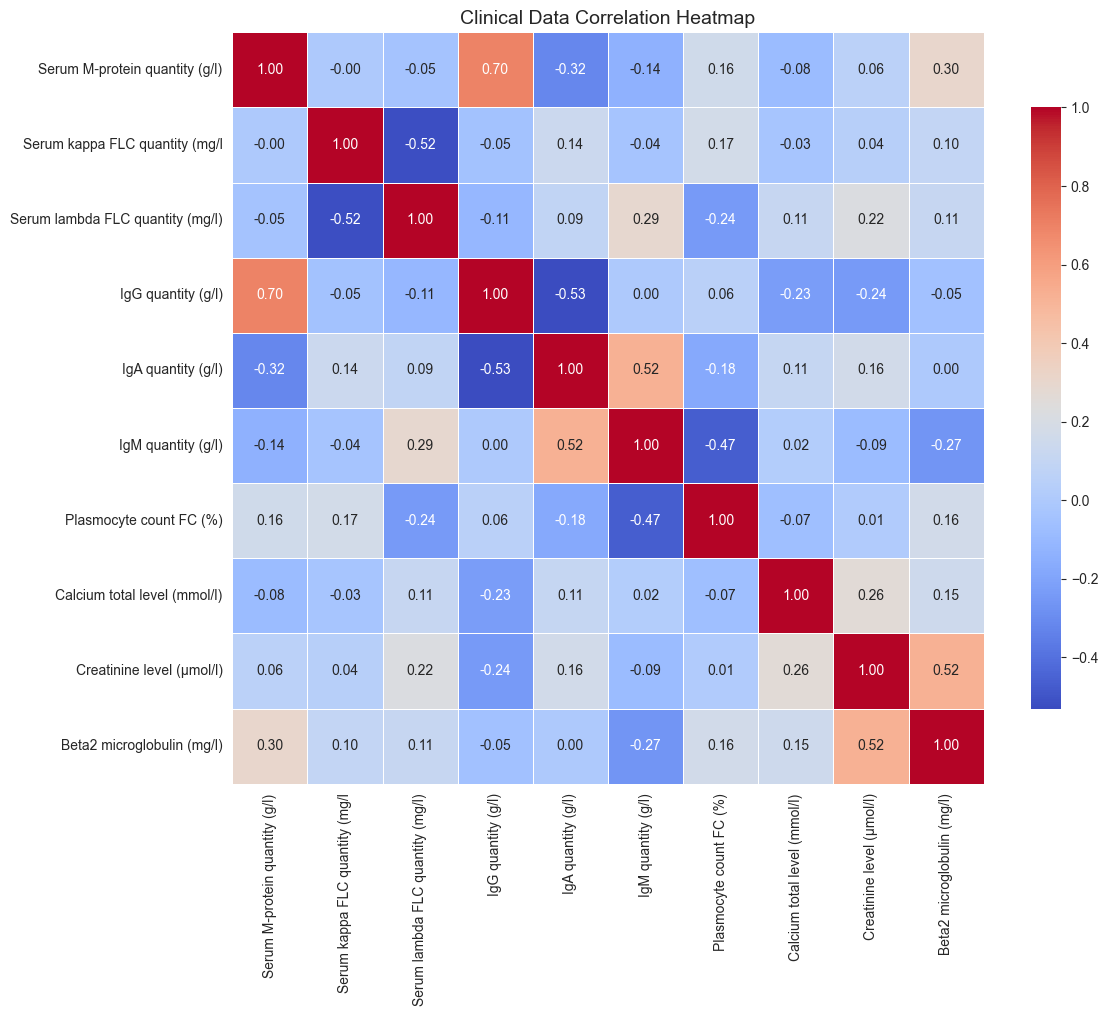

In [16]:
# HEATMAP
plt.figure(figsize=(12,10))
corr = df.corr(method="spearman")  # pearson/spearman
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True, linewidths=0.5, cbar_kws={"shrink": 0.8})
plt.title("Clinical Data Correlation Heatmap", fontsize=14)
plt.tight_layout()
plt.show()

ANALYSIS BETWEEN IMAGE TYPES

In [41]:
# Load lesions datasets
df_c25 = pd.read_csv(r"D:\DP\CSV\merged_CaSupp_25_radiomics_spine_lesions_features.csv")
df_c25 = df_c25.drop(columns=["patient"])

df_konv = pd.read_csv(r"D:\DP\CSV\merged_konv_radiomics_spine_lesions_features.csv")
df_konv = df_konv.drop(columns=["patient"])

df_vmi40 = pd.read_csv(r"D:\DP\CSV\merged_monoe_40kev_radiomics_spine_lesions_features.csv")
df_vmi40 = df_vmi40.drop(columns=["patient"])

df_vmi80 = pd.read_csv(r"D:\DP\CSV\merged_monoe_80kev_radiomics_spine_lesions_features.csv")
df_vmi80 = df_vmi80.drop(columns=["patient"])

df_vmi120 = pd.read_csv(r"D:\DP\CSV\merged_monoe_120kev_radiomics_spine_lesions_features.csv")
df_vmi120 = df_vmi120.drop(columns=["patient"])

In [43]:
scaler = StandardScaler()

df_c25 = pd.DataFrame(scaler.fit_transform(df_c25), columns=df_c25.columns)
df_konv = pd.DataFrame(scaler.fit_transform(df_konv), columns=df_konv.columns)
df_vmi40 = pd.DataFrame(scaler.fit_transform(df_vmi40), columns=df_vmi40.columns)
df_vmi80 = pd.DataFrame(scaler.fit_transform(df_vmi80), columns=df_vmi80.columns)
df_vmi120 = pd.DataFrame(scaler.fit_transform(df_vmi120), columns=df_vmi120.columns)

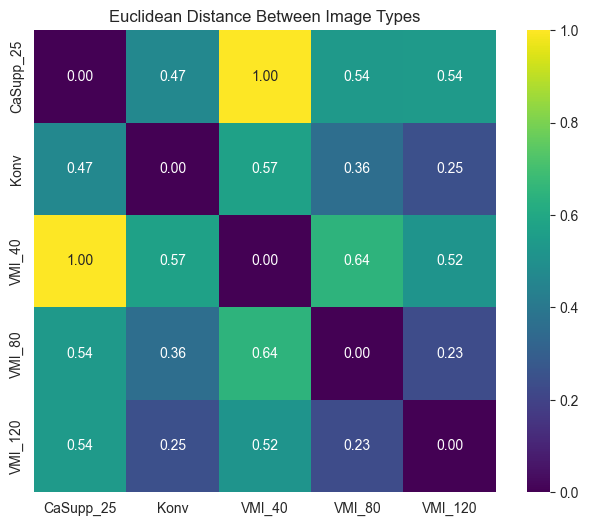

In [44]:
# datasets
datasets = {
    "CaSupp_25": df_c25,
    "Konv": df_konv,
    "VMI_40": df_vmi40,
    "VMI_80": df_vmi80,
    "VMI_120": df_vmi120
}

dataset_names = list(datasets.keys())
n_datasets = len(datasets)

# Initialize distance matrix
euclid_matrix = np.zeros((n_datasets, n_datasets))

# Compute Euclidean distance between mean feature vectors of each dataset pair
for i in range(n_datasets):
    for j in range(n_datasets):
        vec_i = datasets[dataset_names[i]].mean(axis=0).values
        vec_j = datasets[dataset_names[j]].mean(axis=0).values
        euclid_matrix[i, j] = np.linalg.norm(vec_i - vec_j)  # Euclidean distance

min_val = euclid_matrix.min()
max_val = euclid_matrix.max()
euclid_matrix_norm = (euclid_matrix - min_val) / (max_val - min_val)

# --- Convert to DataFrame for readability ---
euclid_df_norm = pd.DataFrame(euclid_matrix_norm, index=dataset_names, columns=dataset_names)

plt.figure(figsize=(8,6))
sns.heatmap(euclid_df_norm, annot=True, fmt=".2f", cmap="viridis", square=True)
plt.title("Euclidean Distance Between Image Types")
plt.show()